# Bond Freeze/Break Retrosynthetic Planning

This notebook demonstrates how target-bond annotations change retrosynthetic search results.

The comparison is deterministic for review:

- **Baseline**: `bonds_state=None`.
- **Constrained**: `Breaking bonds = []`, `Freezing Bonds = [(7, 8), (16, 17)]`.

A frozen bond is encoded as state `2`. During rule application, SynPlanner composes each candidate reaction into a Chython CGR and rejects the candidate if a frozen atom pair appears as a broken `DynamicBond` (`order is not None`, `p_order is None`). State `1` marks a bond as allowed to break and does not reject candidates.

The notebook reports route counts, cluster counts, and whether selected frozen bonds appear in any cluster's `strat_bonds`.

In [27]:
from pathlib import Path
from synplan.utils.loading import download_preset

# Download preset data (or use already downloaded)
paths = download_preset("synplanner-article", save_to="synplan_data")

# input data
ranking_policy_network = paths["ranking_policy"]
reaction_rules_path = paths["reaction_rules"]
building_blocks_path = paths["building_blocks"]

# output folder (shared with other tutorials)
results_folder = Path("tutorial_results").resolve()
results_folder.mkdir(exist_ok=True)

In [28]:
from synplan.utils.loading import (
    load_building_blocks,
    load_evaluation_function,
    load_policy_function,
    load_reaction_rules,
)

building_blocks = load_building_blocks(
    building_blocks_path,
    standardize=True,
    silent=False,
)
reaction_rules = load_reaction_rules(reaction_rules_path)
policy_function = load_policy_function(weights_path=ranking_policy_network)

Lightning automatically upgraded your loaded checkpoint from v1.9.5 to v2.6.0. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint synplan_data/policy/supervised_gcn/v1/v1/ranking_policy.ckpt`


In [29]:
from synplan.utils.config import RolloutEvaluationConfig, TreeConfig

tree_config = TreeConfig(
    search_strategy="expansion_first",
    max_iterations=300,
    max_time=120,
    max_depth=9,
    min_mol_size=1,
    init_node_value=0.5,
    ucb_type="uct",
    c_ucb=0.1,
)

eval_config = RolloutEvaluationConfig(
    policy_network=policy_function,
    reaction_rules=reaction_rules,
    building_blocks=building_blocks,
    min_mol_size=tree_config.min_mol_size,
    max_depth=tree_config.max_depth,
)
evaluation_function = load_evaluation_function(eval_config)

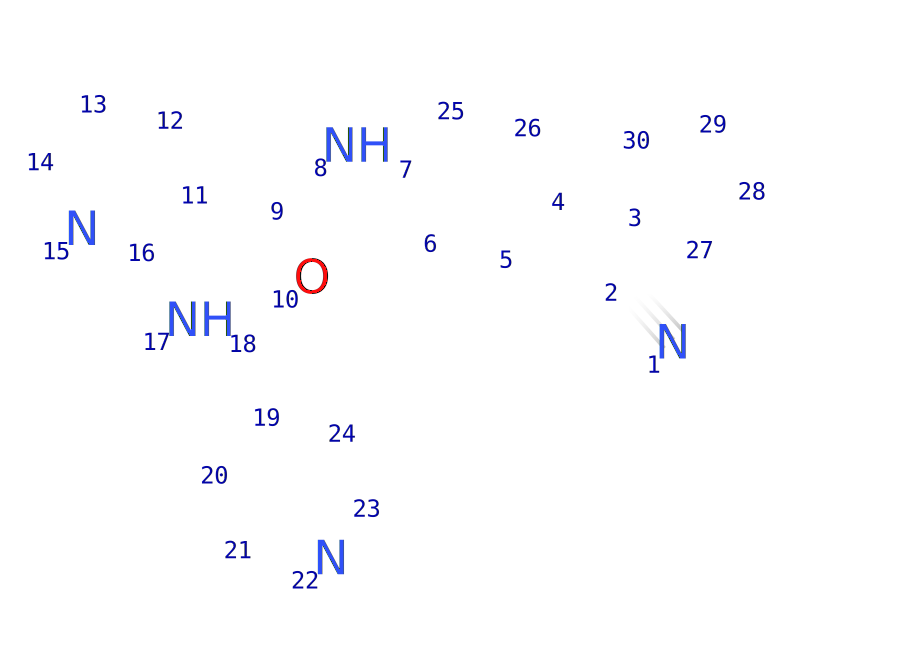

In [30]:
from IPython.display import SVG, display
from chython import depict_settings
from synplan.chem.utils import mol_from_smiles

depict_settings(aam=True)

# Review target molecule used for the bond-freeze comparison.
example_smiles = "N#CC1(c2ccc(NC(=O)c3cccnc3NCc3ccncc3)cc2)CCCC1"
target_molecule = mol_from_smiles(
    example_smiles,
    clean2d=True,
    standardize=True,
    clean_stereo=True,
)

display(SVG(target_molecule.depict(format="svg", width="900px", height="650px")))

### Clickable widget

In [ ]:
# import math
# import anywidget
# import traitlets
# from IPython.display import display
# from chython import depict_settings

# depict_settings(aam=True)  # show Chython atom numbers

# break_bonds = []
# freeze_bonds = []


# class ChythonBondSelector(anywidget.AnyWidget):
#     _esm = r"""
#     function fmt(pairs) {
#       return "[" + pairs.map(p => "(" + p[0] + ", " + p[1] + ")").join(", ") + "]";
#     }

#     function pairsFor(state, wanted) {
#       return Object.entries(state)
#         .filter(([_, v]) => Number(v) === wanted)
#         .map(([k, _]) => k.split("-").map(Number));
#     }

#     function render({ model, el }) {
#       el.classList.add("chython-bond-selector");

#       const holder = document.createElement("div");
#       const labels = document.createElement("div");
#       labels.className = "bond-lists";
#       el.append(holder, labels);

#       let state = {};

#       function paint() {
#         holder.querySelectorAll(".bond-selection").forEach(line => {
#           const mode = Number(state[line.dataset.bond] || 0);
#           line.setAttribute("stroke", mode === 1 ? "red" : mode === 2 ? "blue" : "transparent");
#           line.setAttribute("stroke-width", mode === 0 ? "0.01" : model.get("select_width"));
#         });

#         labels.innerHTML =
#           "<b>Breaking bonds</b>: " + fmt(pairsFor(state, 1)) +
#           "<br><b>Freezing Bonds</b>: " + fmt(pairsFor(state, 2));
#       }

#       function attachSvg() {
#         holder.innerHTML = model.get("svg");
#         state = { ...model.get("state") };

#         holder.querySelectorAll(".bond-hit").forEach(line => {
#           line.addEventListener("click", event => {
#             event.stopPropagation();
#             const key = event.currentTarget.dataset.bond;
#             state[key] = (Number(state[key] || 0) + 1) % 3;
#             model.set("state", { ...state });
#             model.save_changes();
#             paint();
#           });
#         });

#         paint();
#       }

#       model.on("change:svg", attachSvg);
#       model.on("change:state", () => {
#         state = { ...model.get("state") };
#         paint();
#       });

#       attachSvg();
#     }

#     export default { render };
#     """

#     _css = """
#     .chython-bond-selector svg {
#       max-width: 100%;
#       height: auto;
#     }
#     .chython-bond-selector .bond-hit {
#       cursor: pointer;
#     }
#     .chython-bond-selector .bond-lists {
#       margin-top: 8px;
#       font-family: monospace;
#       font-size: 14px;
#     }
#     """

#     svg = traitlets.Unicode().tag(sync=True)
#     state = traitlets.Dict().tag(sync=True)
#     select_width = traitlets.Float(0.14).tag(sync=True)

#     def __init__(self, mol, break_bonds, freeze_bonds, **kwargs):
#         self.mol = mol
#         self._break_bonds = break_bonds
#         self._freeze_bonds = freeze_bonds

#         try:
#             self.mol.clean2d()
#         except Exception:
#             pass

#         initial_state = {
#             f"{min(a, b)}-{max(a, b)}": 0
#             for a, b, _ in self.mol.bonds()
#         }

#         super().__init__(
#             svg=self._svg_with_click_targets(),
#             state=initial_state,
#             **kwargs,
#         )

#         self.observe(self._state_changed, names="state")
#         self._sync_lists()

#     def _svg_with_click_targets(self):
#         svg = self.mol.depict(format="svg")

#         atoms = {n: a for n, a in self.mol.atoms()}
#         overlays = [
#             '<g class="bond-selection-layer" fill="none" stroke-linecap="round" pointer-events="none">'
#         ]

#         hit_lines = [
#             '<g class="bond-hit-layer" fill="none" stroke="black" stroke-opacity="0" '
#             'stroke-width="0.45" stroke-linecap="round" pointer-events="stroke">'
#         ]

#         for a, b, _ in self.mol.bonds():
#             a, b = min(a, b), max(a, b)
#             key = f"{a}-{b}"

#             x1, y1 = float(atoms[a].x), -float(atoms[a].y)
#             x2, y2 = float(atoms[b].x), -float(atoms[b].y)

#             dx, dy = x2 - x1, y2 - y1
#             length = math.hypot(dx, dy)
#             shorten = min(0.18, length * 0.25) if length else 0
#             ux, uy = (dx / length, dy / length) if length else (0, 0)

#             sx1, sy1 = x1 + ux * shorten, y1 + uy * shorten
#             sx2, sy2 = x2 - ux * shorten, y2 - uy * shorten

#             overlays.append(
#                 f'<line class="bond-selection" data-bond="{key}" '
#                 f'x1="{sx1:.3f}" y1="{sy1:.3f}" x2="{sx2:.3f}" y2="{sy2:.3f}" '
#                 f'stroke="transparent" stroke-width="0.01"/>'
#             )
#             hit_lines.append(
#                 f'<line class="bond-hit" data-bond="{key}" '
#                 f'x1="{x1:.3f}" y1="{y1:.3f}" x2="{x2:.3f}" y2="{y2:.3f}"/>'
#             )

#         overlays.append("</g>")
#         hit_lines.append("</g>")

#         insert = "\n".join(overlays + hit_lines)
#         return svg.rsplit("</svg>", 1)[0] + insert + "\n</svg>"

#     def _state_changed(self, change):
#         self._sync_lists()

#     def _sync_lists(self):
#         self._break_bonds[:] = sorted(
#             tuple(map(int, k.split("-")))
#             for k, v in self.state.items()
#             if int(v) == 1
#         )
#         self._freeze_bonds[:] = sorted(
#             tuple(map(int, k.split("-")))
#             for k, v in self.state.items()
#             if int(v) == 2
#         )


# selector = ChythonBondSelector(target_molecule, break_bonds, freeze_bonds)
# display(selector)


## Fixed Bond Selection

The review scenario freezes two target bonds and leaves the break list empty. The `bonds_state` object is normalized here, not inside the reaction engine, so downstream code receives tuple-keyed state directly:

```python
{(7, 8): 2, (16, 17): 2}
```

All other target bonds remain at state `0`.

Breaking bonds: []
Freezing Bonds: [(7, 8), (16, 17)]


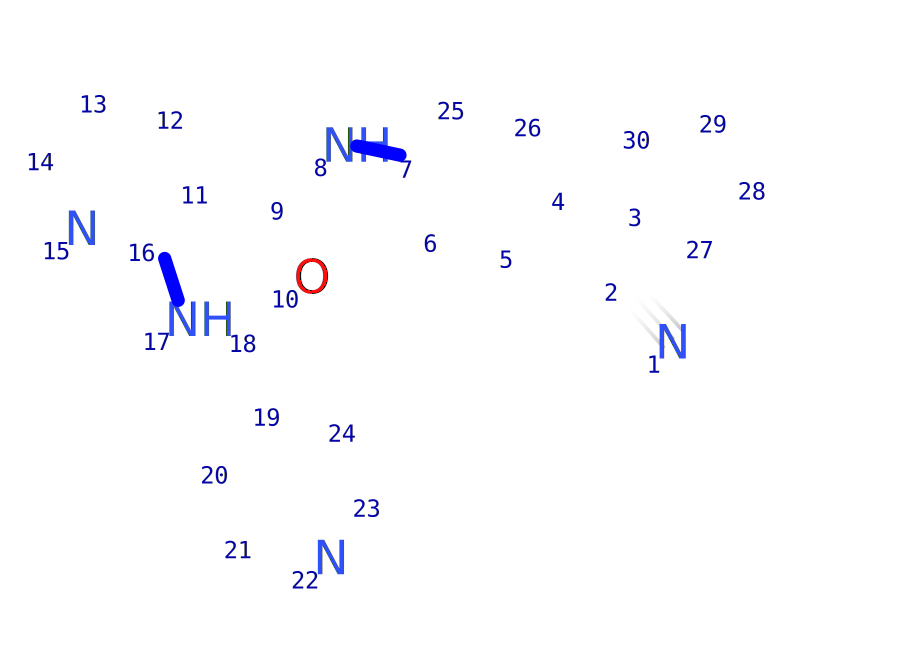

In [31]:
import math

SELECTED_BREAKING_BONDS = []
SELECTED_FREEZING_BONDS = [(7, 8), (16, 17)]


def bond_key(pair):
    a, b = pair
    return tuple(sorted((int(a), int(b))))


def make_bonds_state(mol, breaking_bonds=(), freezing_bonds=()):
    target_bonds = {bond_key((a, b)) for a, b, _ in mol.bonds()}
    state = {bond: 0 for bond in sorted(target_bonds)}

    requested_bonds = {bond_key(bond) for bond in (*breaking_bonds, *freezing_bonds)}
    missing_bonds = sorted(requested_bonds - target_bonds)
    if missing_bonds:
        raise ValueError(f"Selected bonds are not present in target: {missing_bonds}")

    for bond in breaking_bonds:
        state[bond_key(bond)] = 1
    for bond in freezing_bonds:
        state[bond_key(bond)] = 2

    return state


def selected_bonds_svg(mol, bonds_state, width="900px", height="650px"):
    base_svg = mol.depict(format="svg", width=width, height=height)
    atoms = {n: atom for n, atom in mol.atoms()}
    lines = ['<g fill="none" stroke-linecap="round" pointer-events="none">']

    for atom1, atom2 in sorted(bonds_state):
        mode = bonds_state[(atom1, atom2)]
        if mode == 0:
            continue

        color = "red" if mode == 1 else "blue"
        x1, y1 = float(atoms[atom1].x), -float(atoms[atom1].y)
        x2, y2 = float(atoms[atom2].x), -float(atoms[atom2].y)
        dx, dy = x2 - x1, y2 - y1
        length = math.hypot(dx, dy)
        shorten = min(0.18, length * 0.25) if length else 0
        ux, uy = (dx / length, dy / length) if length else (0, 0)

        lines.append(
            f'<line x1="{x1 + ux * shorten:.3f}" y1="{y1 + uy * shorten:.3f}" '
            f'x2="{x2 - ux * shorten:.3f}" y2="{y2 - uy * shorten:.3f}" '
            f'stroke="{color}" stroke-width="0.14"/>'
        )

    lines.append("</g>")
    return base_svg.rsplit("</svg>", 1)[0] + "\n" + "\n".join(lines) + "\n</svg>"


bonds_state = make_bonds_state(
    target_molecule,
    breaking_bonds=SELECTED_BREAKING_BONDS,
    freezing_bonds=SELECTED_FREEZING_BONDS,
)
break_bonds = sorted(bond for bond, state in bonds_state.items() if state == 1)
freeze_bonds = sorted(bond for bond, state in bonds_state.items() if state == 2)

print(f"Breaking bonds: {break_bonds}")
print(f"Freezing Bonds: {freeze_bonds}")
display(SVG(selected_bonds_svg(target_molecule, bonds_state)))

## Search And Clustering Helpers

Both scenarios use identical search configuration, policy, evaluation function, reaction rules, and building-block set. Only `bonds_state` changes.

In [56]:
import pandas as pd

from synplan.chem.reaction_routes.clustering import cluster_routes
from synplan.chem.reaction_routes.route_cgr import compose_all_route_cgrs, compose_all_sb_cgrs
from synplan.mcts.tree import Tree


def run_search(label, bonds_state=None):
    tree = Tree(
        target=target_molecule,
        config=tree_config,
        reaction_rules=reaction_rules,
        building_blocks=building_blocks,
        expansion_function=policy_function,
        evaluation_function=evaluation_function,
        bonds_state=bonds_state,
    )

    found_route = False
    for solved, _node_id in tree:
        found_route = found_route or solved

    print(
        f"{label}: routes={len(tree.winning_nodes)}, "
        f"unique_route_ids={len(set(tree.winning_nodes))}, "
        f"found_route={found_route}"
    )
    return tree


def cluster_tree(tree):
    route_cgrs = compose_all_route_cgrs(tree)
    sb_cgrs = compose_all_sb_cgrs(route_cgrs)
    clusters = cluster_routes(sb_cgrs, use_strat=True)
    return route_cgrs, sb_cgrs, clusters


def selected_frozen_strat_bond_hits(clusters, frozen_bonds):
    frozen_bonds = set(frozen_bonds)
    records = []
    for cluster_id, cluster in clusters.items():
        strat_bonds = set(cluster.get("strat_bonds") or [])
        present = sorted(strat_bonds & frozen_bonds)
        if present:
            records.append(
                {
                    "cluster_id": cluster_id,
                    "group_size": cluster.get("group_size", len(cluster.get("route_ids", []))),
                    "selected_freezing_bonds_in_strat_bonds": present,
                    "strat_bonds": sorted(strat_bonds),
                    "route_ids": cluster.get("route_ids", []),
                }
            )
    return records


def cluster_summary_rows(label, clusters, frozen_bonds):
    rows = []
    frozen_bonds = set(frozen_bonds)
    for cluster_id, cluster in clusters.items():
        strat_bonds = sorted(cluster.get("strat_bonds") or [])
        rows.append(
            {
                "scenario": label,
                "cluster_id": cluster_id,
                "group_size": cluster.get("group_size", len(cluster.get("route_ids", []))),
                "strat_bonds": strat_bonds,
                "contains_selected_freezing_bond": bool(set(strat_bonds) & frozen_bonds),
            }
        )
    return rows

## Run Baseline And Frozen-Bond Searches

In [57]:
baseline_tree = run_search("Baseline (bonds_state=None)", bonds_state=None)
frozen_tree = run_search("Frozen bonds", bonds_state=bonds_state)

  0%|          | 0/300 [00:00<?, ?it/s]

Baseline (bonds_state=None): routes=503, unique_route_ids=503, found_route=True


  0%|          | 0/300 [00:00<?, ?it/s]

Frozen bonds: routes=402, unique_route_ids=402, found_route=True


## Compare Route And Cluster Counts

In [58]:
baseline_route_cgrs, baseline_sb_cgrs, baseline_clusters = cluster_tree(baseline_tree)
frozen_route_cgrs, frozen_sb_cgrs, frozen_clusters = cluster_tree(frozen_tree)

baseline_hits = selected_frozen_strat_bond_hits(baseline_clusters, freeze_bonds)
frozen_hits = selected_frozen_strat_bond_hits(frozen_clusters, freeze_bonds)

summary = pd.DataFrame(
    [
        {
            "scenario": "Baseline (bonds_state=None)",
            "routes_found": len(baseline_tree.winning_nodes),
            "route_cgrs_composed": len(baseline_route_cgrs),
            "clusters": len(baseline_clusters),
            "clusters_with_selected_freezing_as_strat_bonds": len(baseline_hits),
        },
        {
            "scenario": "Frozen bonds [(7, 8), (16, 17)]",
            "routes_found": len(frozen_tree.winning_nodes),
            "route_cgrs_composed": len(frozen_route_cgrs),
            "clusters": len(frozen_clusters),
            "clusters_with_selected_freezing_as_strat_bonds": len(frozen_hits),
        },
    ]
)

numeric_columns = [
    "routes_found",
    "clusters",
    "clusters_with_selected_freezing_as_strat_bonds",
]
delta = summary.loc[1, numeric_columns] - summary.loc[0, numeric_columns]
# summary.loc[1, [f"delta_{col}" for col in numeric_columns]] = delta.to_list()
# summary.loc[0, [f"delta_{col}" for col in numeric_columns]] = 0
summary

,scenario,routes_found,route_cgrs_composed,clusters,clusters_with_selected_freezing_as_strat_bonds
0,Baseline (bonds_state=None),503,503,26,21
1,"Frozen bonds [(7, 8), (16, 17)]",402,402,8,0


In [ ]:
# route_delta = len(frozen_tree.winning_nodes) - len(baseline_tree.winning_nodes)
# cluster_delta = len(frozen_clusters) - len(baseline_clusters)

# print(f"Route count delta (frozen - baseline): {route_delta}")
# print(f"Cluster count delta (frozen - baseline): {cluster_delta}")
# print(f"Selected frozen bonds: {freeze_bonds}")

## Check Selected Frozen Bonds In Cluster `strat_bonds`

The next tables explicitly check whether `(7, 8)` or `(16, 17)` appears in each scenario's cluster-level `strat_bonds`.

### Venn-style comparison by `strat_bonds`

The Venn-style chart below compares baseline and experiment clusters by their `strat_bonds` patterns rather than by `cluster_id`. The left-only baseline region is split into the three requested categories: patterns containing only `(16, 17)`, only `(7, 8)`, or both selected frozen bonds.

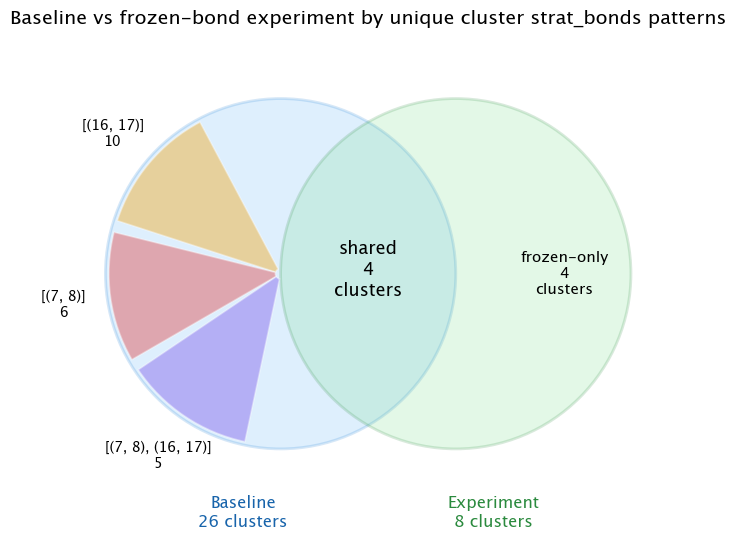

,region,unique_strat_bonds_patterns,baseline_cluster_ids,experiment_cluster_ids
0,shared baseline/experiment,4,4,4
1,"baseline-only containing [(16, 17)]",10,10,0
2,"baseline-only containing [(7, 8)]",6,6,0
3,"baseline-only containing [(7, 8), (16, 17)]",5,5,0
4,"baseline-only, no selected frozen bond",1,1,0
5,experiment-only,4,0,4


In [66]:
from collections import defaultdict

import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Wedge


def strat_pattern(cluster):
    return tuple(sorted(cluster.get("strat_bonds") or []))


def build_strat_pattern_index(clusters):
    index = defaultdict(list)
    for cluster_id, cluster in clusters.items():
        index[strat_pattern(cluster)].append(cluster_id)
    return dict(index)


baseline_pattern_index = build_strat_pattern_index(baseline_clusters)
frozen_pattern_index = build_strat_pattern_index(frozen_clusters)

baseline_patterns = set(baseline_pattern_index)
frozen_patterns = set(frozen_pattern_index)
shared_patterns = baseline_patterns & frozen_patterns
baseline_only_patterns = baseline_patterns - frozen_patterns
frozen_only_patterns = frozen_patterns - baseline_patterns

bond_78 = (7, 8)
bond_1617 = (16, 17)
segment_definitions = [
    ("[(16, 17)]", {bond_1617}, "#f59f00"),
    ("[(7, 8)]", {bond_78}, "#e03131"),
    ("[(7, 8), (16, 17)]", {bond_78, bond_1617}, "#7048e8"),
]

baseline_only_segments = {}
for label, required_bonds, color in segment_definitions:
    patterns = {
        pattern
        for pattern in baseline_only_patterns
        if set(pattern) & set(freeze_bonds) == required_bonds
    }
    baseline_only_segments[label] = {
        "patterns": patterns,
        "color": color,
        "cluster_ids": [
            cluster_id
            for pattern in patterns
            for cluster_id in baseline_pattern_index[pattern]
        ],
    }

baseline_only_other = {
    pattern
    for pattern in baseline_only_patterns
    if not (set(pattern) & set(freeze_bonds))
}

venn_rows = [
    {
        "region": "shared baseline/experiment",
        "unique_strat_bonds_patterns": len(shared_patterns),
        "baseline_cluster_ids": sum(len(baseline_pattern_index[p]) for p in shared_patterns),
        "experiment_cluster_ids": sum(len(frozen_pattern_index[p]) for p in shared_patterns),
    }
]
for label, segment in baseline_only_segments.items():
    venn_rows.append(
        {
            "region": f"baseline-only containing {label}",
            "unique_strat_bonds_patterns": len(segment["patterns"]),
            "baseline_cluster_ids": len(segment["cluster_ids"]),
            "experiment_cluster_ids": 0,
        }
    )
venn_rows.extend(
    [
        {
            "region": "baseline-only, no selected frozen bond",
            "unique_strat_bonds_patterns": len(baseline_only_other),
            "baseline_cluster_ids": sum(
                len(baseline_pattern_index[p]) for p in baseline_only_other
            ),
            "experiment_cluster_ids": 0,
        },
        {
            "region": "experiment-only",
            "unique_strat_bonds_patterns": len(frozen_only_patterns),
            "baseline_cluster_ids": 0,
            "experiment_cluster_ids": sum(
                len(frozen_pattern_index[p]) for p in frozen_only_patterns
            ),
        },
    ]
)
venn_summary = pd.DataFrame(venn_rows)

fig, ax = plt.subplots(figsize=(11, 6.5))
ax.set_aspect("equal")
ax.axis("off")

left_center = (-1.05, 0.0)
right_center = (1.05, 0.0)
radius = 2.1

# Base circles. Areas are intentionally schematic, not count-proportional.
ax.add_patch(Circle(left_center, radius, facecolor="#4dabf7", alpha=0.18, edgecolor="#1c7ed6", linewidth=2.0))
ax.add_patch(Circle(right_center, radius, facecolor="#69db7c", alpha=0.18, edgecolor="#2b8a3e", linewidth=2.0))

# Split the baseline-only side into the requested three categories.
wedge_angles = [(118, 162), (166, 210), (214, 258)]
for (label, _required_bonds, color), (theta1, theta2) in zip(segment_definitions, wedge_angles):
    count = len(baseline_only_segments[label]["patterns"])
    ax.add_patch(
        Wedge(
            left_center,
            radius * 0.98,
            theta1,
            theta2,
            width=radius * 0.95,
            facecolor=color,
            alpha=0.38,
            edgecolor="white",
            linewidth=1.2,
        )
    )
    theta = (theta1 + theta2) / 2
    x = left_center[0] + 1.25 * radius * math.cos(math.radians(theta))
    y = left_center[1] + 1.25 * radius * math.sin(math.radians(theta))
    ax.text(x, y, f"{label}\n{count}", ha="center", va="center", fontsize=10)

ax.text(
    left_center[0] - 0.45,
    -2.65,
    f"Baseline\n{len(baseline_clusters)} clusters",
    ha="center",
    va="top",
    fontsize=12,
    color="#1864ab",
    fontweight="bold",
)
ax.text(
    right_center[0] + 0.45,
    -2.65,
    f"Experiment\n{len(frozen_clusters)} clusters",
    ha="center",
    va="top",
    fontsize=12,
    color="#2b8a3e",
    fontweight="bold",
)
ax.text(
    0,
    0.05,
    f"shared\n{len(shared_patterns)}\nclusters",
    ha="center",
    va="center",
    fontsize=13,
    fontweight="bold",
)
ax.text(
    2.35,
    0,
    f"frozen-only\n{len(frozen_only_patterns)}\nclusters",
    ha="center",
    va="center",
    fontsize=11,
)
# ax.text(
#     -2.95,
#     1.55,
#     f"baseline-only other\n{len(baseline_only_other)}\npatterns",
#     ha="center",
#     va="center",
#     fontsize=10,
#     color="#495057",
# )

ax.set_xlim(-4.1, 4.1)
ax.set_ylim(-3.3, 2.7)
ax.set_title(
    "Baseline vs frozen-bond experiment by unique cluster strat_bonds patterns",
    fontsize=14,
    pad=18,
)
plt.show()

display(venn_summary)


### All clusters in Frozen Experiment

In [60]:
for cluster_key, cluster in frozen_clusters.items():
    print(f"Cluster {cluster_key}:")
    sb_cgr = cluster['sb_cgr']
    sb_cgr.clean2d()
    display(sb_cgr)

Cluster 2.1:


Cluster 2.2:


Cluster 3.1:


Cluster 3.2:


Cluster 3.3:


Cluster 3.4:


Cluster 5.1:


Cluster 6.1:


### Unique clusters in Frozen Experiment

In [79]:
routes_nums = []
for pattern in frozen_only_patterns:
    un_cl = frozen_pattern_index[pattern][0]
    print(un_cl)
    num = frozen_clusters[un_cl]['group_size']
    routes_nums.append(num)
    sb_cgr = frozen_clusters[un_cl]['sb_cgr']
    sb_cgr.clean2d()
    display(sb_cgr)
print('Total new routes:', sum(routes_nums) )

3.4


6.1


3.1


5.1


Total new routes: 44


In [ ]:
# hit_records = []
# for scenario, hits in (
#     ("Baseline (bonds_state=None)", baseline_hits),
#     ("Frozen bonds [(7, 8), (16, 17)]", frozen_hits),
# ):
#     for record in hits:
#         hit_records.append({"scenario": scenario, **record})

# hit_table = pd.DataFrame(
#     hit_records,
#     columns=[
#         "scenario",
#         "cluster_id",
#         "group_size",
#         "selected_freezing_bonds_in_strat_bonds",
#         "strat_bonds",
#     ],
# )

# if hit_table.empty:
#     print("Selected frozen bonds do not appear in any cluster strat_bonds for either scenario.")
# else:
#     display(hit_table)

In [68]:
cluster_details_baseline = pd.DataFrame(
    cluster_summary_rows("Baseline (bonds_state=None)", baseline_clusters, freeze_bonds)
)
cluster_details_frozen = pd.DataFrame(
    cluster_summary_rows("Frozen bonds [(7, 8), (16, 17)]", frozen_clusters, freeze_bonds)
)

with pd.option_context("display.max_rows", None, "display.max_colwidth", None):
    display(cluster_details_baseline.sort_values(["scenario", "cluster_id"]))
    display(cluster_details_frozen.sort_values(["scenario", "cluster_id"]))

,scenario,cluster_id,group_size,strat_bonds,contains_selected_freezing_bond
0,Baseline (bonds_state=None),2.1,7,"[(7, 8), (9, 10)]",True
1,Baseline (bonds_state=None),2.2,7,"[(7, 8), (16, 17)]",True
2,Baseline (bonds_state=None),2.3,8,"[(7, 8), (17, 18)]",True
3,Baseline (bonds_state=None),2.4,10,"[(8, 9), (9, 10)]",False
4,Baseline (bonds_state=None),2.5,66,"[(8, 9), (16, 17)]",True
5,Baseline (bonds_state=None),2.6,122,"[(8, 9), (17, 18)]",False
6,Baseline (bonds_state=None),3.1,2,"[(3, 4), (7, 8), (16, 17)]",True
7,Baseline (bonds_state=None),3.2,16,"[(3, 4), (8, 9), (16, 17)]",True
8,Baseline (bonds_state=None),3.3,20,"[(7, 8), (8, 9), (9, 10)]",True
9,Baseline (bonds_state=None),3.4,42,"[(7, 8), (8, 9), (16, 17)]",True


,scenario,cluster_id,group_size,strat_bonds,contains_selected_freezing_bond
0,"Frozen bonds [(7, 8), (16, 17)]",2.1,20,"[(8, 9), (9, 10)]",False
1,"Frozen bonds [(7, 8), (16, 17)]",2.2,279,"[(8, 9), (17, 18)]",False
2,"Frozen bonds [(7, 8), (16, 17)]",3.1,16,"[(3, 4), (8, 9), (17, 18)]",False
3,"Frozen bonds [(7, 8), (16, 17)]",3.2,21,"[(8, 9), (9, 10), (17, 18)]",False
4,"Frozen bonds [(7, 8), (16, 17)]",3.3,38,"[(8, 9), (9, 11), (17, 18)]",False
5,"Frozen bonds [(7, 8), (16, 17)]",3.4,10,"[(8, 9), (17, 18), (18, 19)]",False
6,"Frozen bonds [(7, 8), (16, 17)]",5.1,17,"[(2, 3), (3, 27), (3, 30), (8, 9), (17, 18)]",False
7,"Frozen bonds [(7, 8), (16, 17)]",6.1,1,"[(1, 2), (2, 3), (3, 27), (3, 30), (8, 9), (17, 18)]",False


### The Venn diagram showed that by selecting which bonds to freeze, we managed to create new routes that were not explored by baseline - frozen only 4 clusters ( 44 routes in total)

## Review Notes

For peer review, the comparison should be interpreted at two levels:

1. **Search-level effect**: compare `routes_found` and `unique_route_ids` between baseline and frozen-bond runs.
2. **Strategy-level effect**: compare `clusters`, `clustered_routes`, and whether selected frozen bonds appear in cluster `strat_bonds`.

The frozen-bond condition is evaluated per candidate reaction before products are yielded, so it changes which branches enter the tree rather than filtering routes after the search.